In [1]:
import pandas as pd

In [2]:
data_temp = pd.read_csv('/lustre/geocean/WORK/users/alonsoap/personal/dodencia/AnaliticaDeDatos/datos/clases/clase_2_analisis_de_series_temporales/datos_temp.csv', skiprows=3)

In [3]:
data_temp.head()

,time,temperature_2m (°C)
0,2000-01-01T00:00,-0.1
1,2000-01-01T01:00,-0.2
2,2000-01-01T02:00,-0.1
3,2000-01-01T03:00,-0.2
4,2000-01-01T04:00,-0.2


Cuando trabajeis con una serie temporal, lo primero es importante que la columna de fechas esté en formato datetime. Para ello, podemos usar la función pd.to_datetime() de pandas.

In [4]:
data_temp['time'] = pd.to_datetime(data_temp['time']) #### Esta función convierte la columna 'time' a un objeto de tipo datetime, lo que permite realizar operaciones de series temporales

Es conveniente además que es en el indice

In [5]:
#data_temp = data_temp.set_index('time') # Esta es una forma de hacerlo
data_temp.set_index('time', inplace=True) #### Esta función establece la columna 'time' como índice del DataFrame, lo que es útil para análisis de series temporales
data_temp.rename(columns={'temperature_2m (°C)': 'temperature'}, inplace=True) #### Esta función renombra la columna de temperatura para simplificar su nombre

In [6]:
data_temp

,temperature
time,
2000-01-01 00:00:00,-0.1
2000-01-01 01:00:00,-0.2
2000-01-01 02:00:00,-0.1
2000-01-01 03:00:00,-0.2
2000-01-01 04:00:00,-0.2
...,...
2025-12-31 19:00:00,1.4
2025-12-31 20:00:00,1.6
2025-12-31 21:00:00,1.7


Lo primero es empezar a pintar los datos, con un grafico simple podemos ver el periodo que cubren. La libreria principal para pintar que vamos a utilizar es matplotlib.pyplot

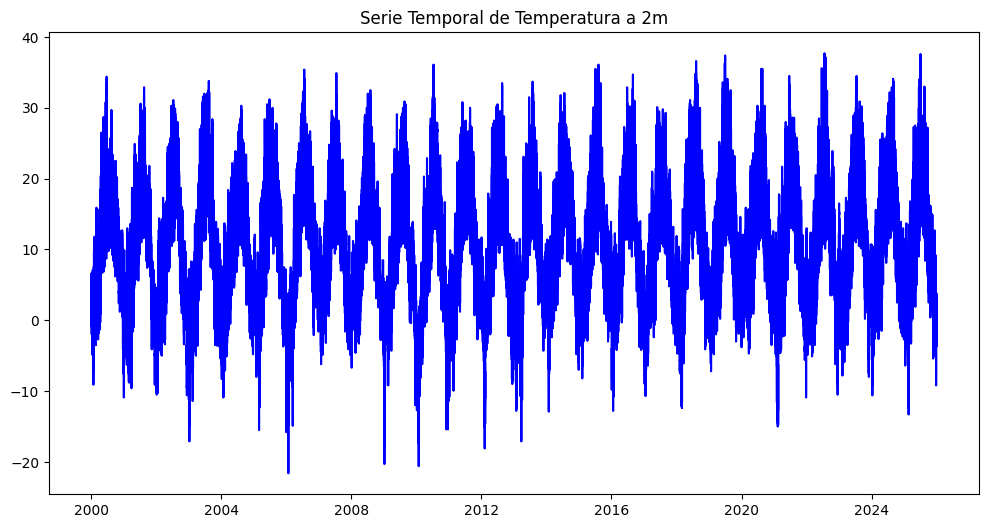

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6)) #### Asi creo un grafico nuevo. fisize=(12, 6) define el tamaño del grafico en pulgadas. 12 de ancho y 6 de alto

ax.plot(data_temp.index, data_temp['temperature'], color='blue', label='Temperatura a 2m') #### Esta función traza la serie temporal de temperatura en el eje x (data_temp.index) y el eje y (data_temp['temperature']). El color del grafico es azul y se le asigna una etiqueta para la leyenda
ax.set_title('Serie Temporal de Temperatura a 2m') #### Esta función establece el título del grafico

plt.show() #### Esta función muestra el grafico generado

La serie temporal es horaria. Nos puede interesar explorar en otras frecuencias. Por ejemplo, podemos obtener medias diarias

In [8]:
data_temp_daily_mean = data_temp.resample('D').mean() #### Esta función re-muestrea los datos a una frecuencia diaria ('D') y calcula la media de la temperatura para cada día
data_temp_daily_min = data_temp.resample('D').min() 
data_temp_daily_max = data_temp.resample('D').max()

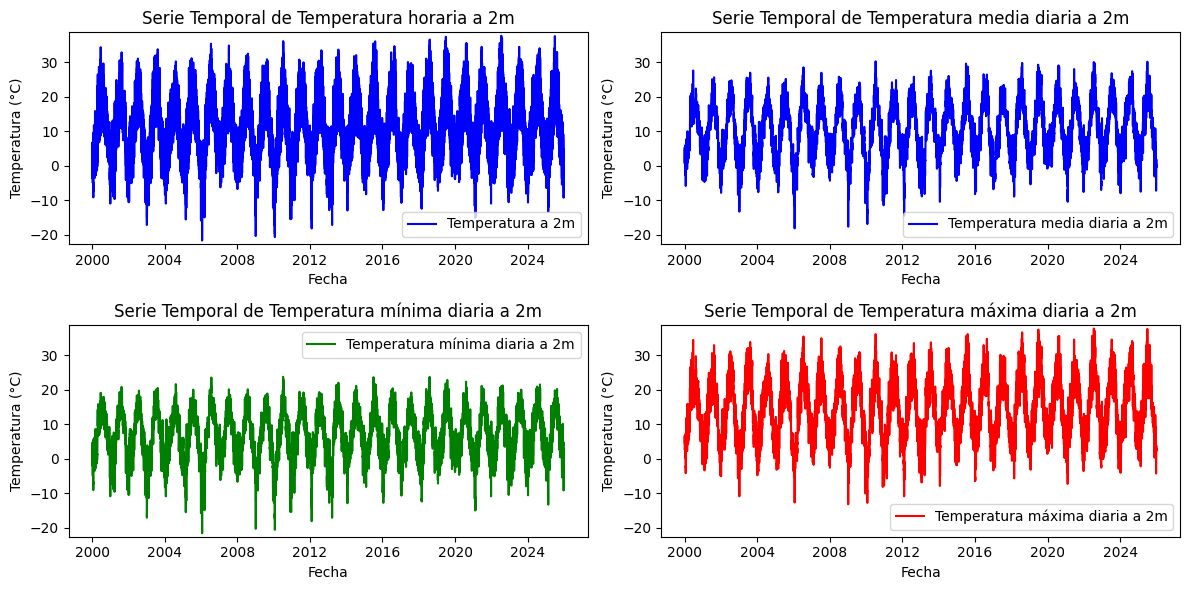

In [9]:
fig, axes = plt.subplots(2,2, figsize=(12, 6))

temp_min = data_temp_daily_min['temperature'].min()
temp_max = data_temp_daily_max['temperature'].max()

axes[0,0].plot(data_temp.index, data_temp['temperature'], color='blue', label='Temperatura a 2m') #### Esta función traza la serie temporal de temperatura en el eje x (data_temp.index) y el eje y (data_temp['temperature']). El color del grafico es azul y se le asigna una etiqueta para la leyenda
axes[0,0].set_title('Serie Temporal de Temperatura horaria a 2m')

axes[0,1].plot(data_temp_daily_mean.index, data_temp_daily_mean['temperature'], color='blue', label='Temperatura media diaria a 2m') #### Esta función traza la serie temporal de temperatura media diaria en el eje x (data_temp_daily_mean.index) y el eje y (data_temp_daily_mean['temperature']). El color del grafico es azul y se le asigna una etiqueta para la leyenda
axes[0,1].set_title('Serie Temporal de Temperatura media diaria a 2m') #### Esta función establece el título del grafico    

axes[1,0].plot(data_temp_daily_min.index, data_temp_daily_min['temperature'], color='green', label='Temperatura mínima diaria a 2m') #### Esta función traza la serie temporal de temperatura mínima diaria en el eje x (data_temp_daily_min.index) y el eje y (data_temp_daily_min['temperature']). El color del grafico es verde y se le asigna una etiqueta para la leyenda
axes[1,0].set_title('Serie Temporal de Temperatura mínima diaria a 2m') #### Esta función establece el título del grafico

axes[1,1].plot(data_temp_daily_max.index, data_temp_daily_max['temperature'], color='red', label='Temperatura máxima diaria a 2m') #### Esta función traza la serie temporal de temperatura máxima diaria en el eje x (data_temp_daily_max.index) y el eje y (data_temp_daily_max['temperature']). El color del grafico es rojo y se le asigna una etiqueta para la leyenda
axes[1,1].set_title('Serie Temporal de Temperatura máxima diaria a 2m') #### Esta función establece el título del grafico

axes = axes.flatten() #### Esta función aplana la matriz de ejes para facilitar la iteración sobre ellos
for ax in axes:
    ax.set_ylim(temp_min-1, temp_max+1) #### Esta función establece los límites del eje y para todos los subplots, añadiendo un margen de 1 grado por encima y por debajo de la temperatura mínima y máxima respectivamente
    ax.set_xlabel('Fecha') #### Esta función establece la etiqueta del eje x para todos los subplots
    ax.set_ylabel('Temperatura (°C)') #### Esta función establece la etiqueta del eje y para todos los subplots
    ax.legend() #### Esta función añade una leyenda a cada subplot

plt.tight_layout() #### Esta función ajusta automáticamente los subplots para que no se solapen

Tambien podemos agregarlo a escala mensual o anual

In [10]:
data_temp_monthly_mean = data_temp.resample('MS').mean() #### Esta función re-muestrea los datos a una frecuencia mensual ('MS') y calcula la media de la temperatura para cada mes
data_temp_yearly_mean = data_temp.resample('YS').mean() #### Esta función re-muestrea los datos a una frecuencia anual ('YS') y calcula la media de la temperatura para cada año

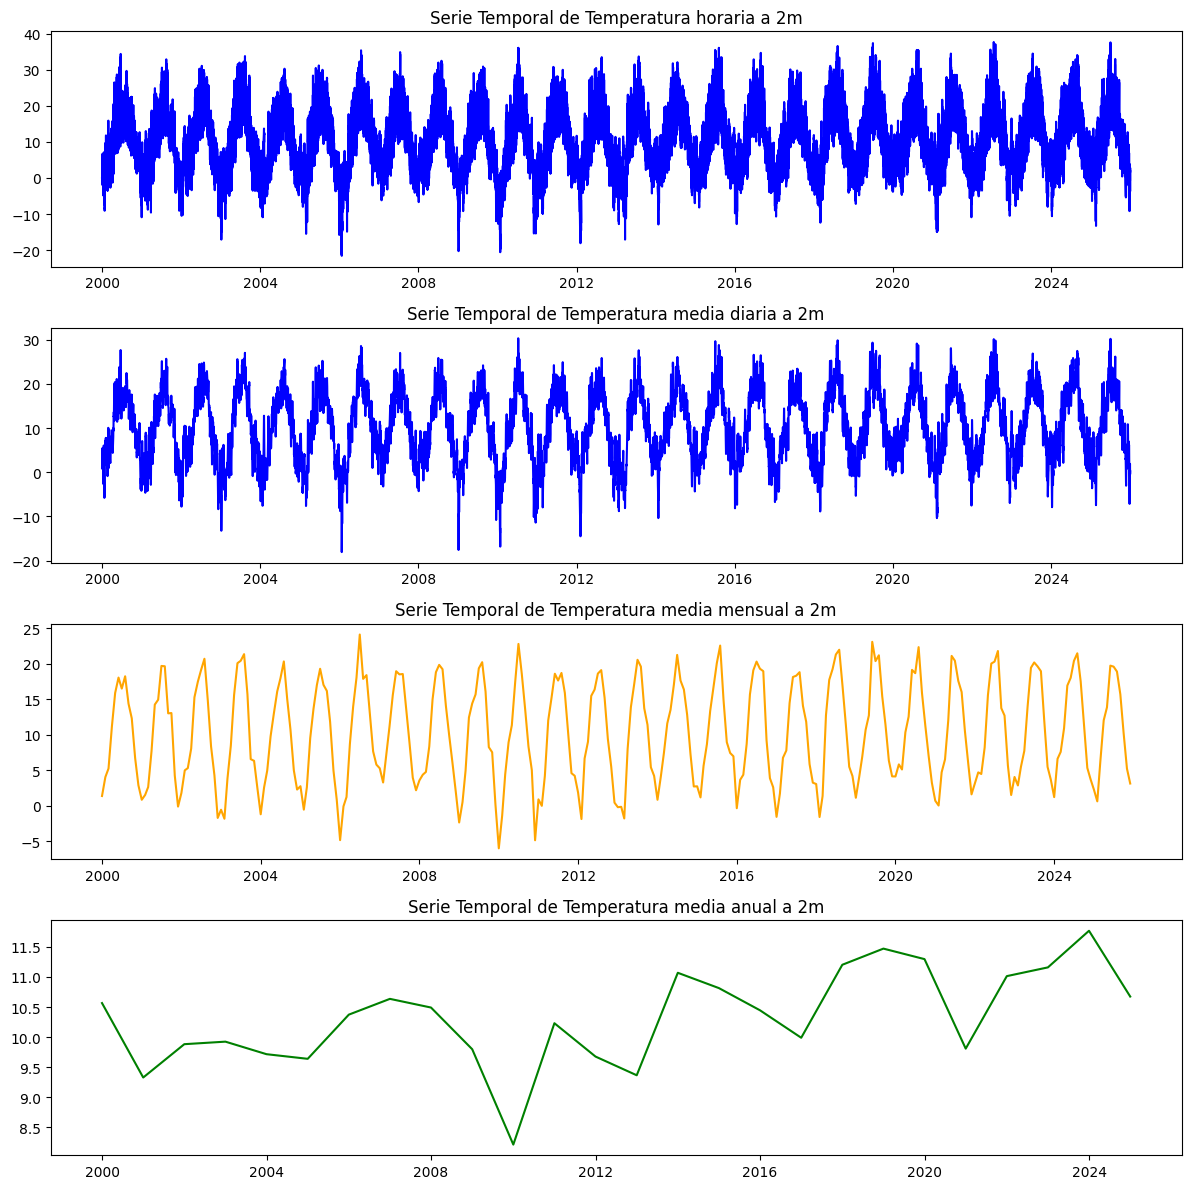

In [11]:
fig, axes = plt.subplots(4,1, figsize=(12, 12))

axes[0].plot(data_temp.index, data_temp['temperature'], color='blue', label='Temperatura a 2m') #### Esta función traza la serie temporal de temperatura en el eje x (data_temp.index) y el eje y (data_temp['temperature']). El color del grafico es azul y se le asigna una etiqueta para la leyenda
axes[0].set_title('Serie Temporal de Temperatura horaria a 2m') 

axes[1].plot(data_temp_daily_mean.index, data_temp_daily_mean['temperature'], color='blue', label='Temperatura media diaria a 2m') #### Esta función traza la serie temporal de temperatura media diaria en el eje x (data_temp_daily_mean.index) y el eje y (data_temp_daily_mean['temperature']). El color del grafico es azul y se le asigna una etiqueta para la leyenda
axes[1].set_title('Serie Temporal de Temperatura media diaria a 2m')

axes[2].plot(data_temp_monthly_mean.index, data_temp_monthly_mean['temperature'], color='orange', label='Temperatura media mensual a 2m') #### Esta función traza la serie temporal de temperatura media mensual en el eje x (data_temp_monthly_mean.index) y el eje y (data_temp_monthly_mean['temperature']). El color del grafico es naranja y se le asigna una etiqueta para la leyenda
axes[2].set_title('Serie Temporal de Temperatura media mensual a 2m')

axes[3].plot(data_temp_yearly_mean.index, data_temp_yearly_mean['temperature'], color='green', label='Temperatura media anual a 2m') #### Esta función traza la serie temporal de temperatura media anual en el eje x (data_temp_yearly_mean.index) y el eje y (data_temp_yearly_mean['temperature']). El color del grafico es verde y se le asigna una etiqueta para la leyenda
axes[3].set_title('Serie Temporal de Temperatura media anual a 2m')

plt.tight_layout() #### Esta función ajusta automáticamente los subplots para que no se solapen
plt.show()

Vamos a hacer una analisis de como varia la temperatura diaría segun el mes. Para eso vamos a crear una variable "dummy" con el nombre del mes

In [12]:
data_temp['month_num'] = data_temp.index.month
for i in range(1,13):
    data_temp.loc[data_temp['month_num'] == i, 'month'] = pd.Timestamp(2020, i, 1).strftime('%B') #### Esta función asigna el nombre del mes a cada fila del DataFrame basado en el número de mes

<Axes: title={'center': 'temperature'}, xlabel='month'>

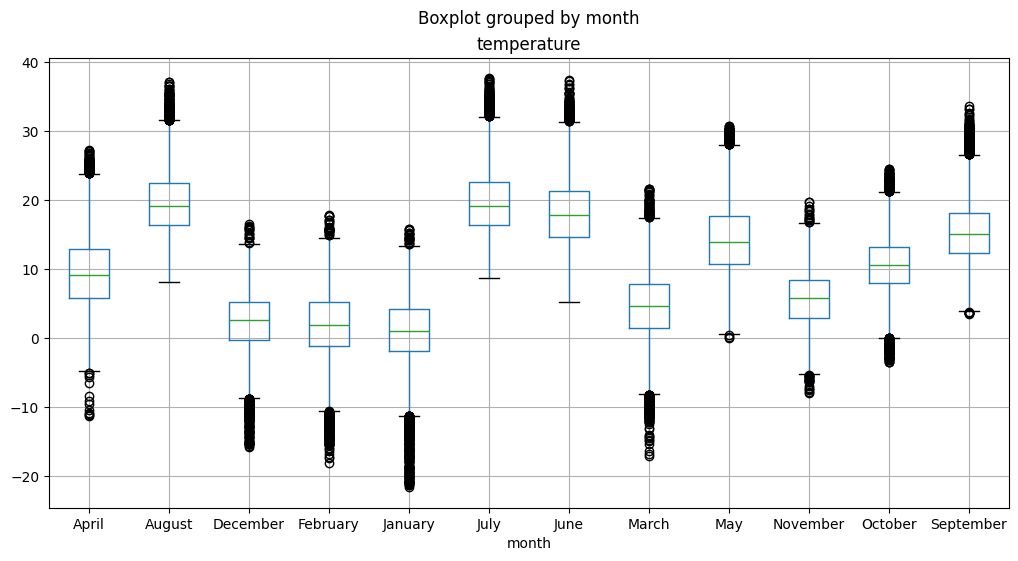

In [13]:
data_temp.boxplot(column='temperature', by='month', figsize=(12, 6)) #### Esta función crea un diagrama de caja (boxplot) de la temperatura agrupada por mes. El parámetro 'by' especifica la columna por la cual se agruparán los datos, y 'figsize' define el tamaño del gráfico

Hemos analizado en el contexto multivariado como se correlacionan dos variables. En el caso de una serie temporal, puede ser interesante saber si existe correlacion entre los valores de la misma variable en diferentes momentos del tiempo. Para ello, podemos utilizar la función autocorrelation_plot de pandas.plotting, que nos permite visualizar la autocorrelación de una serie temporal.

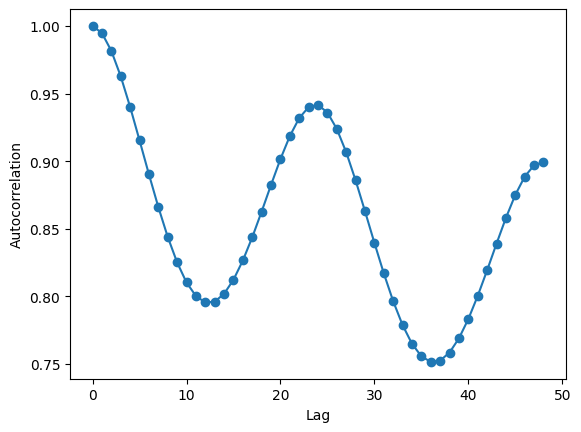

In [14]:
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot

lags = range(49)

autocorrelations = [
    data_temp["temperature"].autocorr(lag=lag)
    for lag in lags
]

plt.plot(lags, autocorrelations, "o-")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

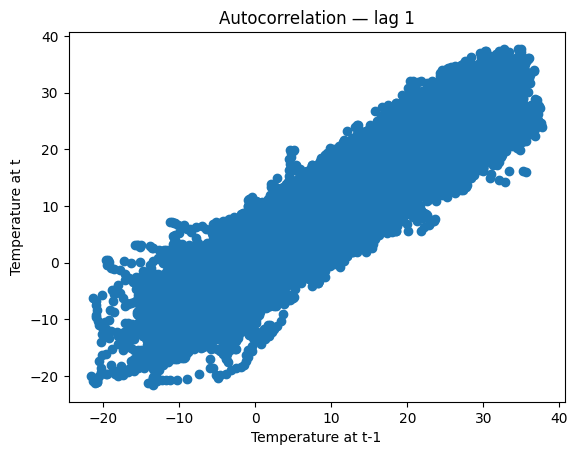

In [15]:
lag = 24

x = data_temp["temperature"].iloc[:-lag]
y = data_temp["temperature"].iloc[lag:]

plt.scatter(x, y)
plt.xlabel("Temperature at t-1")
plt.ylabel("Temperature at t")
plt.title("Autocorrelation — lag 1")
plt.show()

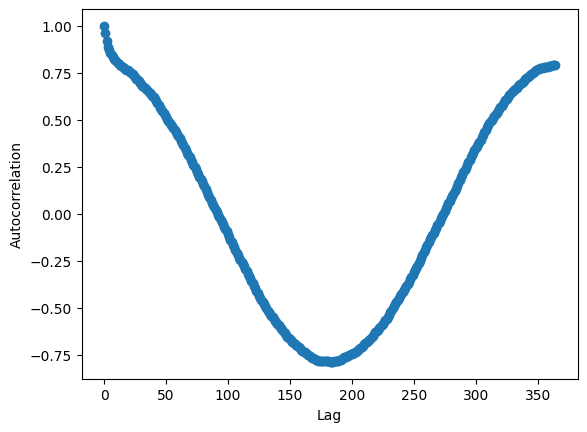

In [16]:
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot

lags = range(365)

autocorrelations = [
    data_temp_daily_mean["temperature"].autocorr(lag=lag)
    for lag in lags
]

plt.plot(lags, autocorrelations, "o-")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

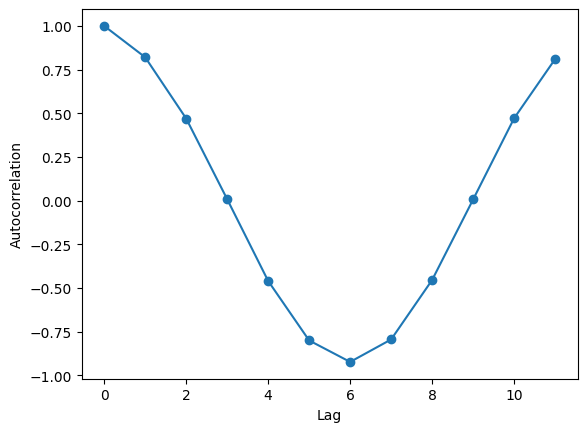

In [17]:
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot

lags = range(12)

autocorrelations = [
    data_temp_monthly_mean["temperature"].autocorr(lag=lag)
    for lag in lags
]

plt.plot(lags, autocorrelations, "o-")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

In [18]:
data_temp_monthly_mean['month'] = data_temp_monthly_mean.index.month

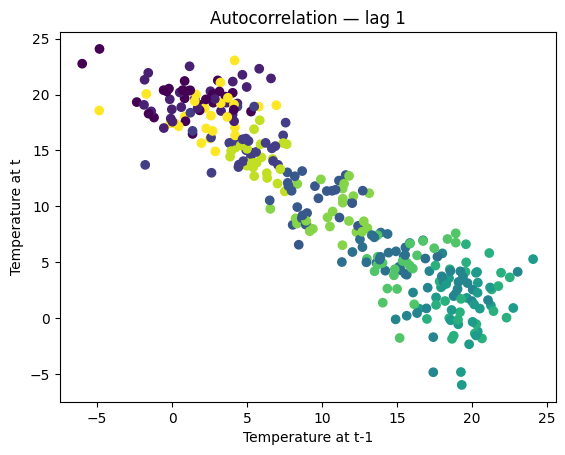

In [19]:
lag = 6

x = data_temp_monthly_mean["temperature"].iloc[:-lag]
y = data_temp_monthly_mean["temperature"].iloc[lag:]

plt.scatter(x, y, c=data_temp_monthly_mean["month"].iloc[:-lag], cmap="viridis")
plt.xlabel("Temperature at t-1")
plt.ylabel("Temperature at t")
plt.title("Autocorrelation — lag 1")
plt.show()

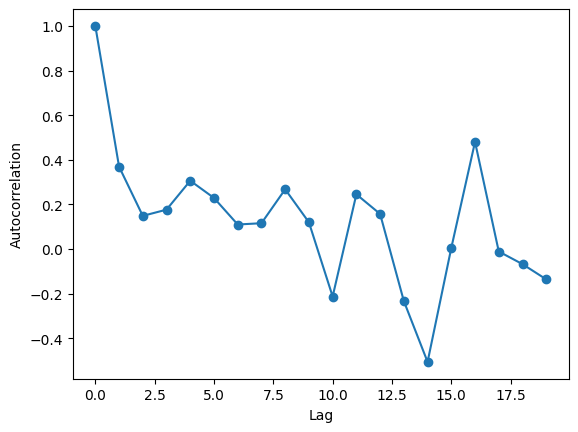

In [20]:
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot

lags = range(20)

autocorrelations = [
    data_temp_yearly_mean["temperature"].autocorr(lag=lag)
    for lag in lags
]

plt.plot(lags, autocorrelations, "o-")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

In [22]:
data_temp_daily_mean['day_of_year'] = data_temp_daily_mean.index.dayofyear

<Axes: xlabel='day_of_year'>

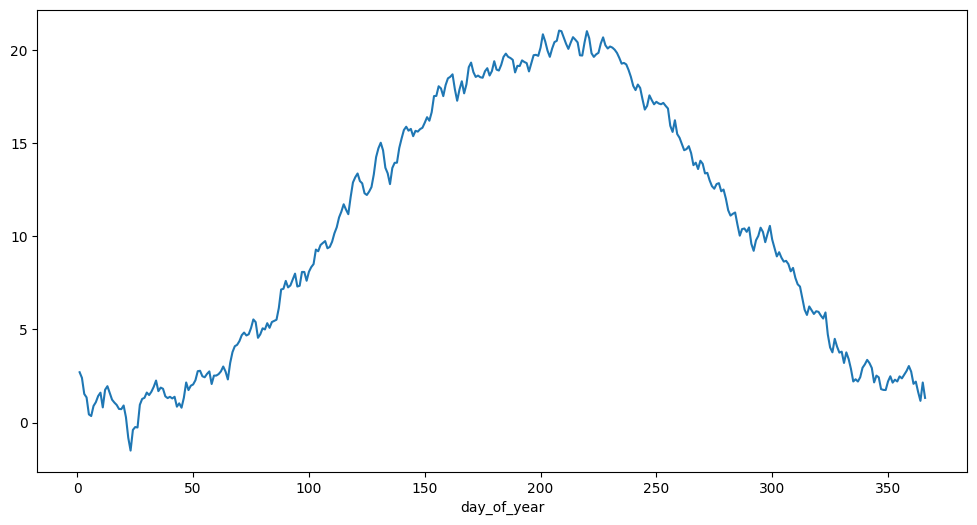

In [23]:
data_temp_daily_mean.groupby('day_of_year')['temperature'].mean().plot(figsize=(12, 6))

In [24]:
day_of_year_mean = data_temp_daily_mean.groupby('day_of_year')['temperature'].mean()

In [25]:
day_of_year_mean.loc[1]

2.6993589743589745

In [26]:
for index, row in data_temp_daily_mean.iterrows():
    print(index)
    print(row)

2000-01-01 00:00:00
temperature    0.875
day_of_year    1.000
Name: 2000-01-01 00:00:00, dtype: float64
2000-01-02 00:00:00
temperature    3.275
day_of_year    2.000
Name: 2000-01-02 00:00:00, dtype: float64
2000-01-03 00:00:00
temperature    5.391667
day_of_year    3.000000
Name: 2000-01-03 00:00:00, dtype: float64
2000-01-04 00:00:00
temperature    5.425
day_of_year    4.000
Name: 2000-01-04 00:00:00, dtype: float64
2000-01-05 00:00:00
temperature    3.55
day_of_year    5.00
Name: 2000-01-05 00:00:00, dtype: float64
2000-01-06 00:00:00
temperature    0.983333
day_of_year    6.000000
Name: 2000-01-06 00:00:00, dtype: float64
2000-01-07 00:00:00
temperature    4.954167
day_of_year    7.000000
Name: 2000-01-07 00:00:00, dtype: float64
2000-01-08 00:00:00
temperature    4.316667
day_of_year    8.000000
Name: 2000-01-08 00:00:00, dtype: float64
2000-01-09 00:00:00
temperature    4.35
day_of_year    9.00
Name: 2000-01-09 00:00:00, dtype: float64
2000-01-10 00:00:00
temperature     1.995833

In [27]:
data_temp_daily_mean['temperature_anomaly'] = data_temp_daily_mean['temperature']
for index, row in data_temp_daily_mean.iterrows():
    
    data_temp_daily_mean.loc[index, 'temperature_anomaly'] = data_temp_daily_mean.loc[index, 'temperature'] - day_of_year_mean.loc[int(row.day_of_year)]

<Axes: xlabel='time'>

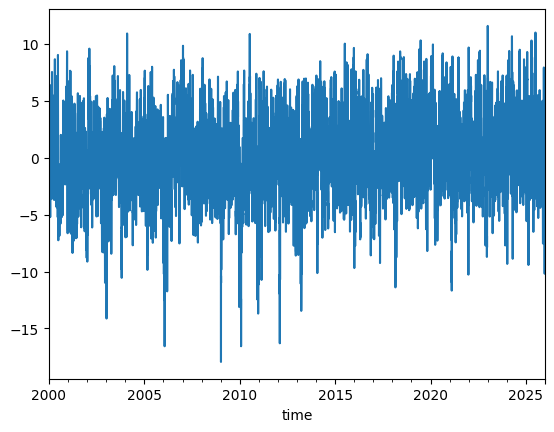

In [28]:
data_temp_daily_mean.temperature_anomaly.plot()

<Axes: xlabel='day_of_year'>

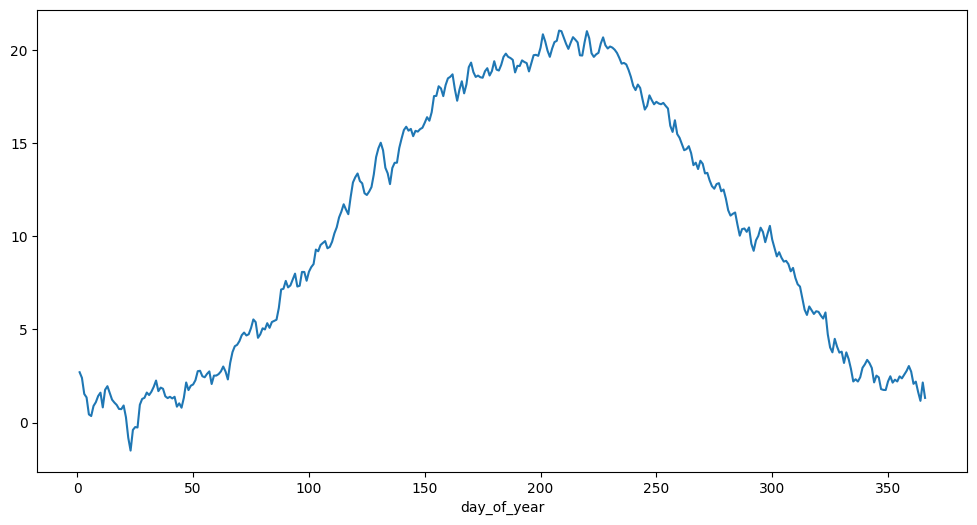

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
day_of_year_mean.plot()